# Bellabeat Case Study: How Can a Wellness Technology Company Play It Smart?

## Business Task

Bellabeat has established itself as a leader in health-focused smart products for women, but the broader smart device market continues to evolve rapidly. To stay ahead, we need a deeper understanding of how consumers are actually using smart devices in their daily lives — not just our own, but across the market. This analysis examines publicly available usage data from non-Bellabeat smart devices to identify key behavioral trends in activity, sleep, and overall wellness tracking. The goal is to translate those findings into actionable recommendations that can directly strengthen the marketing strategy for one of our core products.

Two independent datasets were analyzed to strengthen the reliability of findings:
- **FitBit Fitness Tracker Dataset** — 33 users, 31 days, 2016, US-based
- **LifeSnaps Dataset** — 71 users, 4 months, 2021–2022, European

By analyzing datasets collected five years apart across different geographies and populations, patterns that hold across both carry substantially more weight than findings from either alone.

---
## 2. Data Source: FitBit Fitness Tracker Dataset

The FitBit Fitness Tracker dataset was made available on Kaggle by user Möbius and is licensed under CC0: Public Domain, allowing unrestricted use, modification, and distribution. The underlying data was originally collected through a distributed survey via Amazon Mechanical Turk between March 12 and May 12, 2016, with thirty eligible Fitbit users consenting to the submission of their personal tracker data — though an examination of unique user Ids reveals 33 distinct participants.

The dataset is organized into 18 CSV files exported from Fitabase. All files share a common structure — each row is tied to a user via a unique numeric Id field, and records are timestamped at varying levels of granularity. The data spans a 31-day collection window from April 12 to May 12, 2016.

All participant data is de-identified with no personally identifiable information present.

**Key limitations:** Small sample (33 users), no demographic data, self-selected compensated participants, 10+ years old, 31-day snapshot only, no wear-time indicator, unknown device models.

In [1]:
import pandas as pd
print("Ready to go!")

Ready to go!


In [2]:
# Load the key summary-level files
df_activity = pd.read_csv("Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
df_sleep = pd.read_csv("Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")
df_weight = pd.read_csv("Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv")

print("Daily Activity:", df_activity.shape)
print("Sleep:", df_sleep.shape)
print("Weight:", df_weight.shape)

Daily Activity: (940, 15)
Sleep: (413, 5)
Weight: (67, 8)


In [3]:
df_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


### 2.1 Prepare & Validate

In [4]:
print("Unique users per file:")
print(f"  Daily Activity: {df_activity['Id'].nunique()}")
print(f"  Sleep:          {df_sleep['Id'].nunique()}")
print(f"  Weight:         {df_weight['Id'].nunique()}")

Unique users per file:
  Daily Activity: 33
  Sleep:          24
  Weight:         8


In [5]:
# Convert date columns to consistent format first
df_activity['ActivityDate'] = pd.to_datetime(df_activity['ActivityDate'])
df_sleep['SleepDay'] = pd.to_datetime(df_sleep['SleepDay'])
df_weight['Date'] = pd.to_datetime(df_weight['Date'])

# Check for duplicate user + date combinations
activity_dupes = df_activity.duplicated(subset=['Id', 'ActivityDate']).sum()
sleep_dupes = df_sleep.duplicated(subset=['Id', 'SleepDay']).sum()
weight_dupes = df_weight.duplicated(subset=['Id', 'Date']).sum()

print("Duplicate records (same user + same date):")
print(f"  Daily Activity: {activity_dupes}")
print(f"  Sleep:          {sleep_dupes}")
print(f"  Weight:         {weight_dupes}")

Duplicate records (same user + same date):
  Daily Activity: 0
  Sleep:          3
  Weight:         0


C:\Users\Brenden\AppData\Local\Temp\ipykernel_23988\2225668178.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sleep['SleepDay'] = pd.to_datetime(df_sleep['SleepDay'])
C:\Users\Brenden\AppData\Local\Temp\ipykernel_23988\2225668178.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weight['Date'] = pd.to_datetime(df_weight['Date'])


In [6]:
print("=== Daily Activity - Missing Values ===")
print(df_activity.isnull().sum())
print(f"\n=== Sleep - Missing Values ===")
print(df_sleep.isnull().sum())
print(f"\n=== Weight - Missing Values ===")
print(df_weight.isnull().sum())

=== Daily Activity - Missing Values ===
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

=== Sleep - Missing Values ===
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

=== Weight - Missing Values ===
Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64


In [7]:
print("Date ranges:")
print(f"  Activity: {df_activity['ActivityDate'].min()} to {df_activity['ActivityDate'].max()}")
print(f"  Sleep:    {df_sleep['SleepDay'].min()} to {df_sleep['SleepDay'].max()}")
print(f"  Weight:   {df_weight['Date'].min()} to {df_weight['Date'].max()}")

Date ranges:
  Activity: 2016-04-12 00:00:00 to 2016-05-12 00:00:00
  Sleep:    2016-04-12 00:00:00 to 2016-05-12 00:00:00
  Weight:   2016-04-12 06:47:11 to 2016-05-12 23:59:59


In [8]:
# Do the four activity minute columns add up to 1440 (24 hours)?
df_activity['TotalMinutes'] = (
    df_activity['VeryActiveMinutes'] 
    + df_activity['FairlyActiveMinutes'] 
    + df_activity['LightlyActiveMinutes'] 
    + df_activity['SedentaryMinutes']
)

print("Total minutes per day:")
print(f"  Min:  {df_activity['TotalMinutes'].min()}")
print(f"  Max:  {df_activity['TotalMinutes'].max()}")
print(f"  Mean: {df_activity['TotalMinutes'].mean():.0f}")
print(f"\n  Days equal to 1440: {(df_activity['TotalMinutes'] == 1440).sum()}")
print(f"  Days NOT equal to 1440: {(df_activity['TotalMinutes'] != 1440).sum()}")

Total minutes per day:
  Min:  2
  Max:  1440
  Mean: 1219

  Days equal to 1440: 478
  Days NOT equal to 1440: 462


In [9]:
zero_step_days = (df_activity['TotalSteps'] == 0).sum()
zero_step_users = df_activity[df_activity['TotalSteps'] == 0]['Id'].nunique()

print(f"Days with zero steps: {zero_step_days}")
print(f"Users with at least one zero-step day: {zero_step_users}")

Days with zero steps: 77
Users with at least one zero-step day: 15


In [10]:
print("=== Key Metric Ranges ===\n")

for col in ['TotalSteps', 'TotalDistance', 'Calories', 'SedentaryMinutes']:
    print(f"{col}:")
    print(f"  Min: {df_activity[col].min()}")
    print(f"  Max: {df_activity[col].max()}")
    print(f"  Mean: {df_activity[col].mean():.1f}")
    print(f"  Median: {df_activity[col].median():.1f}")
    print()

=== Key Metric Ranges ===

TotalSteps:
  Min: 0
  Max: 36019
  Mean: 7637.9
  Median: 7405.5

TotalDistance:
  Min: 0.0
  Max: 28.0300006866455
  Mean: 5.5
  Median: 5.2

Calories:
  Min: 0
  Max: 4900
  Mean: 2303.6
  Median: 2134.0

SedentaryMinutes:
  Min: 0
  Max: 1440
  Mean: 991.2
  Median: 1057.5



In [11]:
print("=" * 50)
print("  DATA INTEGRITY SUMMARY")
print("=" * 50)
print(f"\n  Total unique users:        {df_activity['Id'].nunique()}")
print(f"  Users with sleep data:     {df_sleep['Id'].nunique()}")
print(f"  Users with weight data:    {df_weight['Id'].nunique()}")
print(f"  Date range:                {df_activity['ActivityDate'].min().date()} to {df_activity['ActivityDate'].max().date()}")
print(f"  Activity duplicates:       {activity_dupes}")
print(f"  Sleep duplicates:          {sleep_dupes}")
print(f"  Zero-step days:            {zero_step_days}")
print(f"  Days != 1440 minutes:      {(df_activity['TotalMinutes'] != 1440).sum()}")
print(f"  Weight Fat column nulls:   {df_weight['Fat'].isnull().sum()} of {len(df_weight)}")

  DATA INTEGRITY SUMMARY

  Total unique users:        33
  Users with sleep data:     24
  Users with weight data:    8
  Date range:                2016-04-12 to 2016-05-12
  Activity duplicates:       0
  Sleep duplicates:          3
  Zero-step days:            77
  Days != 1440 minutes:      462
  Weight Fat column nulls:   65 of 67


### 2.2 Clean

The cleaning phase resolved integrity issues identified during validation while enriching the dataset with new columns to support deeper analysis. Steps taken:
- Removed 3 duplicate records from the sleep file
- Filtered out zero-step days as likely non-wear days
- Converted date strings to datetime format with explicit format specifications
- Created DayOfWeek, ActivityLevel, TotalActiveMinutes, MinutesAwakeInBed, and SleepEfficiency columns
- Classified users by CDC-aligned activity thresholds (Sedentary, Low Active, Somewhat Active, Active)
- Dropped the nearly empty Fat column from the weight log
- Merged activity and sleep data on user Id and date

In [12]:
# Remove sleep duplicates
print(f"Sleep records before: {len(df_sleep)}")
df_sleep = df_sleep.drop_duplicates(subset=['Id', 'SleepDay'])
print(f"Sleep records after:  {len(df_sleep)}")

Sleep records before: 413
Sleep records after:  410


In [13]:
# Remove zero-step days (likely non-wear days)
print(f"Activity records before: {len(df_activity)}")
df_activity = df_activity[df_activity['TotalSteps'] > 0]
print(f"Activity records after:  {len(df_activity)}")

Activity records before: 940
Activity records after:  863


In [14]:
# Adding new activity level columns
# Day of week for pattern analysis
df_activity['DayOfWeek'] = df_activity['ActivityDate'].dt.day_name()

# Classify users by activity level based on average daily steps
# CDC considers <5000 sedentary, 5000-7499 low active, 
# 7500-9999 somewhat active, 10000+ active
user_avg_steps = df_activity.groupby('Id')['TotalSteps'].mean()

def classify_activity(steps):
    if steps < 5000:
        return 'Sedentary'
    elif steps < 7500:
        return 'Low Active'
    elif steps < 10000:
        return 'Somewhat Active'
    else:
        return 'Active'

user_categories = user_avg_steps.apply(classify_activity).reset_index()
user_categories.columns = ['Id', 'ActivityLevel']

df_activity = df_activity.merge(user_categories, on='Id')

print("Activity level distribution:")
print(df_activity.groupby('ActivityLevel')['Id'].nunique())

Activity level distribution:
ActivityLevel
Active              7
Low Active          9
Sedentary           7
Somewhat Active    10
Name: Id, dtype: int64


In [15]:
df_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,DayOfWeek,ActivityLevel
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,1094,Tuesday,Active
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,1033,Wednesday,Active
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,1440,Thursday,Active
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,998,Friday,Active
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,1040,Saturday,Active


In [16]:
# Create 'TotalActiveMinutes' column
df_activity['TotalActiveMinutes'] = (
    df_activity['VeryActiveMinutes'] 
    + df_activity['FairlyActiveMinutes'] 
    + df_activity['LightlyActiveMinutes']
)

In [17]:
df_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,DayOfWeek,ActivityLevel,TotalActiveMinutes
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,1094,Tuesday,Active,366
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,1033,Wednesday,Active,257
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,1440,Thursday,Active,222
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,998,Friday,Active,272
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,1040,Saturday,Active,267


In [18]:
# Clean sleep data
# Add time awake in bed
df_sleep['MinutesAwakeInBed'] = (
    df_sleep['TotalTimeInBed'] - df_sleep['TotalMinutesAsleep']
)

# Calculate sleep efficiency (percentage of time in bed spent sleeping)
df_sleep['SleepEfficiency'] = (
    df_sleep['TotalMinutesAsleep'] / df_sleep['TotalTimeInBed'] * 100
).round(1)

print(df_sleep[['TotalMinutesAsleep', 'TotalTimeInBed', 
                 'MinutesAwakeInBed', 'SleepEfficiency']].describe())

       TotalMinutesAsleep  TotalTimeInBed  MinutesAwakeInBed  SleepEfficiency
count          410.000000      410.000000         410.000000       410.000000
mean           419.173171      458.482927          39.309756        91.645854
std            118.635918      127.455140          46.710932         8.730261
min             58.000000       61.000000           0.000000        49.800000
25%            361.000000      403.750000          17.000000        91.200000
50%            432.500000      463.000000          25.500000        94.300000
75%            490.000000      526.000000          40.000000        96.100000
max            796.000000      961.000000         371.000000       100.000000


In [19]:
df_sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,MinutesAwakeInBed,SleepEfficiency
0,1503960366,2016-04-12,1,327,346,19,94.5
1,1503960366,2016-04-13,2,384,407,23,94.3
2,1503960366,2016-04-15,1,412,442,30,93.2
3,1503960366,2016-04-16,2,340,367,27,92.6
4,1503960366,2016-04-17,1,700,712,12,98.3


In [20]:
# Merge activity and sleep data...Merge on Id and date
df_sleep['SleepDate'] = df_sleep['SleepDay'].dt.date
df_activity['ActivityDateOnly'] = df_activity['ActivityDate'].dt.date

df_merged = df_activity.merge(
    df_sleep, 
    left_on=['Id', 'ActivityDateOnly'], 
    right_on=['Id', 'SleepDate'], 
    how='left'
)

users_with_both = df_merged.dropna(subset=['TotalMinutesAsleep'])['Id'].nunique()
print(f"Users with both activity and sleep data: {users_with_both}")
print(f"Total merged records: {len(df_merged)}")
print(f"Records with sleep data: {df_merged['TotalMinutesAsleep'].notna().sum()}")

Users with both activity and sleep data: 24
Total merged records: 863
Records with sleep data: 410


In [21]:
df_merged.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,ActivityLevel,TotalActiveMinutes,ActivityDateOnly,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,MinutesAwakeInBed,SleepEfficiency,SleepDate
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,Active,366,2016-04-12,2016-04-12,1.0,327.0,346.0,19.0,94.5,2016-04-12
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,Active,257,2016-04-13,2016-04-13,2.0,384.0,407.0,23.0,94.3,2016-04-13
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,...,Active,222,2016-04-14,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,Active,272,2016-04-15,2016-04-15,1.0,412.0,442.0,30.0,93.2,2016-04-15
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,Active,267,2016-04-16,2016-04-16,2.0,340.0,367.0,27.0,92.6,2016-04-16


In [22]:
# drop fat column due to low particpation
df_weight = df_weight.drop(columns=['Fat'])
print(f"Weight columns remaining: {list(df_weight.columns)}")

Weight columns remaining: ['Id', 'Date', 'WeightKg', 'WeightPounds', 'BMI', 'IsManualReport', 'LogId']


In [23]:
df_weight.head()

,Id,Date,WeightKg,WeightPounds,BMI,IsManualReport,LogId
0,1503960366,2016-05-02 23:59:59,52.599998,115.963147,22.650000,True,1462233599000
1,1503960366,2016-05-03 23:59:59,52.599998,115.963147,22.650000,True,1462319999000
2,1927972279,2016-04-13 01:08:52,133.500000,294.317120,47.540001,False,1460509732000
3,2873212765,2016-04-21 23:59:59,56.700001,125.002104,21.450001,True,1461283199000
4,2873212765,2016-05-12 23:59:59,57.299999,126.324875,21.690001,True,1463097599000


In [24]:
# clean data verification
print("=" * 50)
print("  CLEANED DATA SUMMARY")
print("=" * 50)
print(f"\n  Activity records:     {len(df_activity)}")
print(f"  Activity users:       {df_activity['Id'].nunique()}")
print(f"  Sleep records:        {len(df_sleep)}")
print(f"  Sleep users:          {df_sleep['Id'].nunique()}")
print(f"  Weight records:       {len(df_weight)}")
print(f"  Weight users:         {df_weight['Id'].nunique()}")
print(f"  Merged records:       {len(df_merged)}")
print(f"\n  New columns added:")
print(f"    - DayOfWeek")
print(f"    - ActivityLevel")
print(f"    - TotalActiveMinutes")
print(f"    - MinutesAwakeInBed")
print(f"    - SleepEfficiency")

  CLEANED DATA SUMMARY

  Activity records:     863
  Activity users:       33
  Sleep records:        410
  Sleep users:          24
  Weight records:       67
  Weight users:         8
  Merged records:       863

  New columns added:
    - DayOfWeek
    - ActivityLevel
    - TotalActiveMinutes
    - MinutesAwakeInBed
    - SleepEfficiency


### 2.3 Analyze

In [25]:
# start of analysis
print("=" * 50)
print("  OVERALL USAGE SUMMARY")
print("=" * 50)
print(f"\n  Average daily steps:          {df_activity['TotalSteps'].mean():.0f}")
print(f"  Average daily calories:       {df_activity['Calories'].mean():.0f}")
print(f"  Average active minutes:       {df_activity['TotalActiveMinutes'].mean():.0f}")
print(f"  Average sedentary minutes:    {df_activity['SedentaryMinutes'].mean():.0f}")
print(f"  Average sedentary hours:      {df_activity['SedentaryMinutes'].mean() / 60:.1f}")
print(f"\n  Average sleep (minutes):      {df_sleep['TotalMinutesAsleep'].mean():.0f}")
print(f"  Average sleep (hours):        {df_sleep['TotalMinutesAsleep'].mean() / 60:.1f}")
print(f"  Average sleep efficiency:     {df_sleep['SleepEfficiency'].mean():.1f}%")

  OVERALL USAGE SUMMARY

  Average daily steps:          8319
  Average daily calories:       2361
  Average active minutes:       248
  Average sedentary minutes:    956
  Average sedentary hours:      15.9

  Average sleep (minutes):      419
  Average sleep (hours):        7.0
  Average sleep efficiency:     91.6%


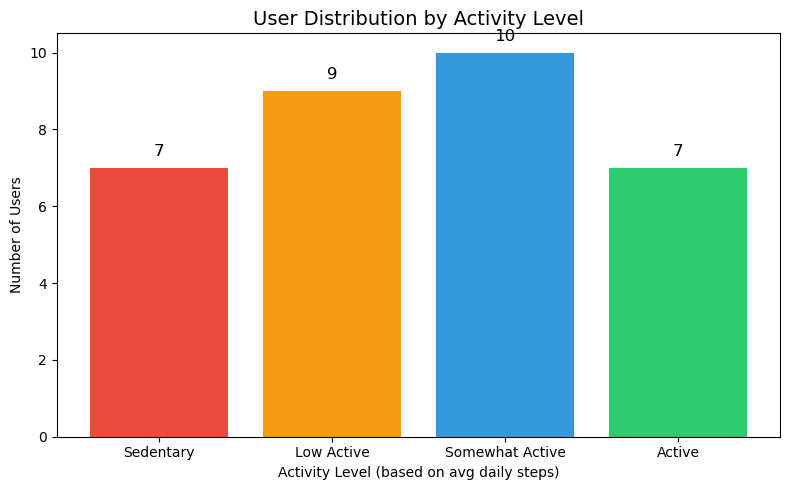

In [26]:
# bar graph depicting activity level classifications of each user
import matplotlib.pyplot as plt

level_counts = df_activity.groupby('ActivityLevel')['Id'].nunique()
level_order = ['Sedentary', 'Low Active', 'Somewhat Active', 'Active']
level_counts = level_counts.reindex(level_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(level_counts.index, level_counts.values, color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'])
plt.title('User Distribution by Activity Level', fontsize=14)
plt.ylabel('Number of Users')
plt.xlabel('Activity Level (based on avg daily steps)')

for bar, count in zip(bars, level_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

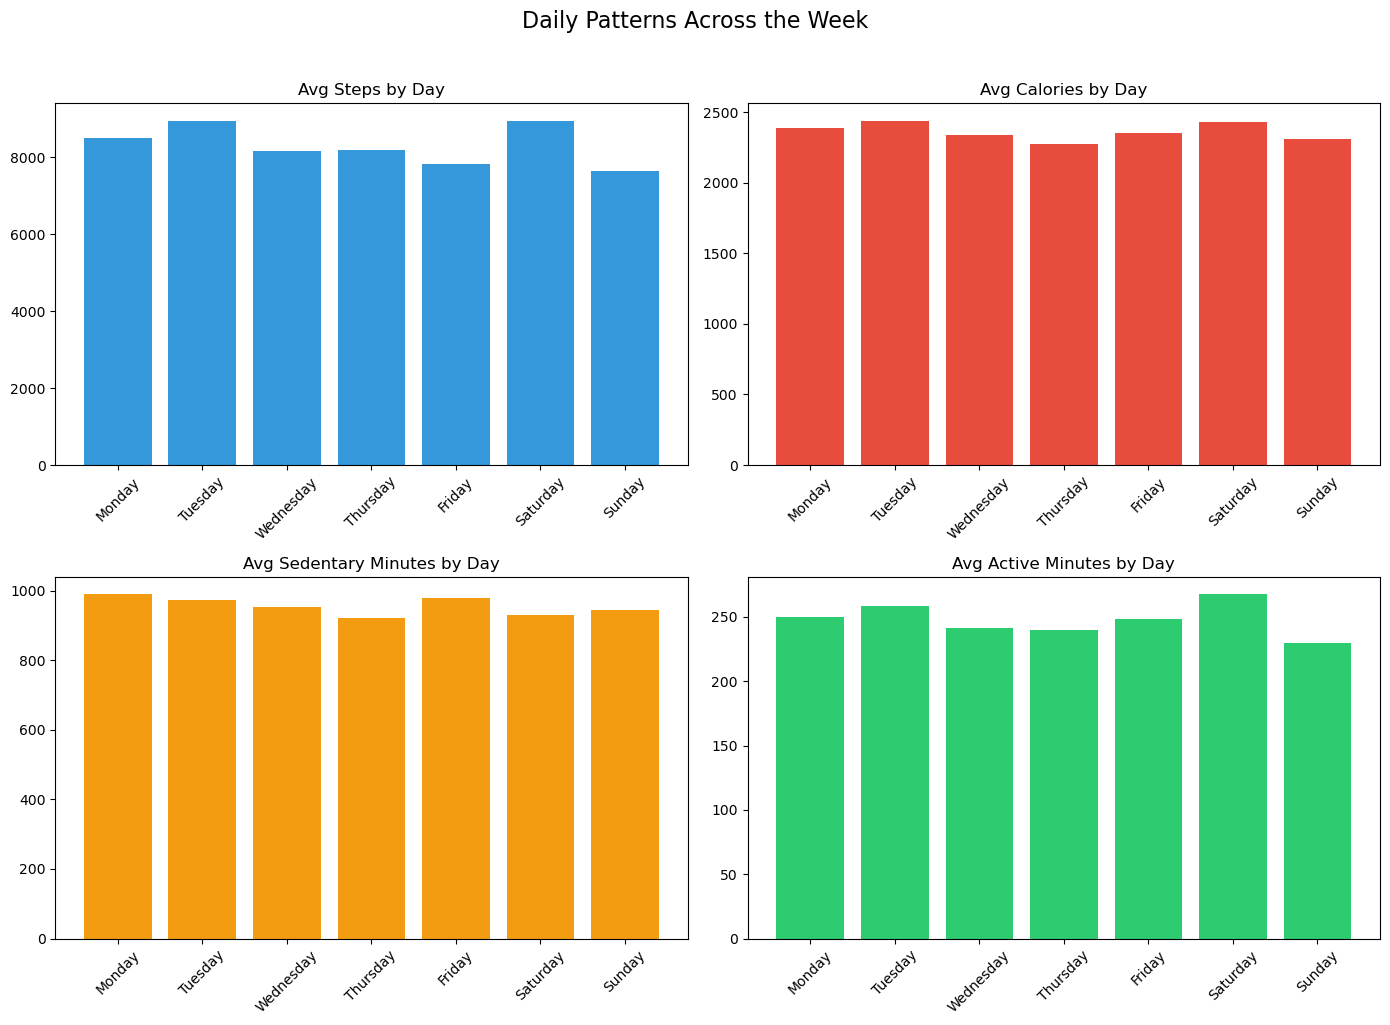

In [27]:
# graph of daily patterns across the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_avg = df_activity.groupby('DayOfWeek').agg({
    'TotalSteps': 'mean',
    'Calories': 'mean',
    'SedentaryMinutes': 'mean',
    'TotalActiveMinutes': 'mean'
}).reindex(day_order)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(daily_avg.index, daily_avg['TotalSteps'], color='#3498db')
axes[0, 0].set_title('Avg Steps by Day')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(daily_avg.index, daily_avg['Calories'], color='#e74c3c')
axes[0, 1].set_title('Avg Calories by Day')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].bar(daily_avg.index, daily_avg['SedentaryMinutes'], color='#f39c12')
axes[1, 0].set_title('Avg Sedentary Minutes by Day')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(daily_avg.index, daily_avg['TotalActiveMinutes'], color='#2ecc71')
axes[1, 1].set_title('Avg Active Minutes by Day')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Daily Patterns Across the Week', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

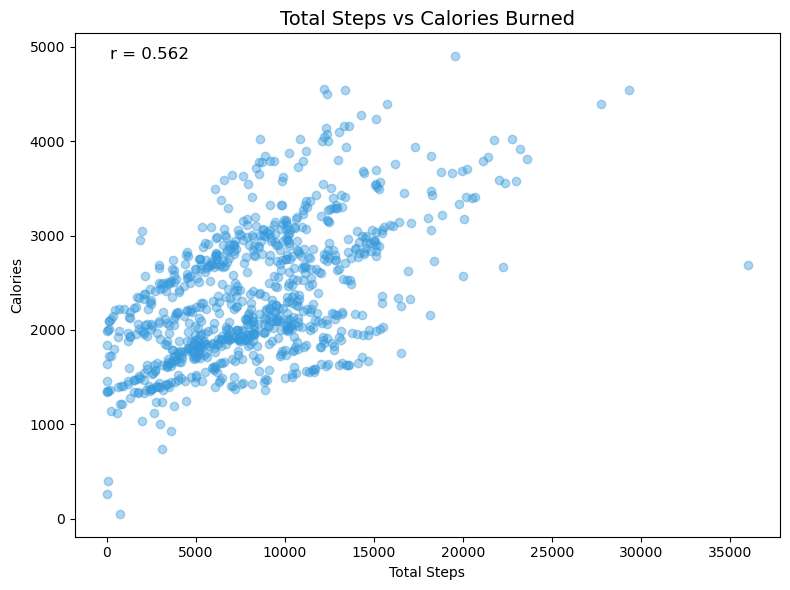

Correlation between steps and calories: 0.562


In [28]:
# scatterplot comparing total steps to calories burnt
plt.figure(figsize=(8, 6))
plt.scatter(df_activity['TotalSteps'], df_activity['Calories'], alpha=0.4, color='#3498db')
plt.title('Total Steps vs Calories Burned', fontsize=14)
plt.xlabel('Total Steps')
plt.ylabel('Calories')

# Add correlation coefficient
correlation = df_activity['TotalSteps'].corr(df_activity['Calories'])
plt.text(0.05, 0.95, f'r = {correlation:.3f}', transform=plt.gca().transAxes, fontsize=12)

plt.tight_layout()
plt.show()
print(f"Correlation between steps and calories: {correlation:.3f}")

In [29]:
# 0.562 = moderate correlation 

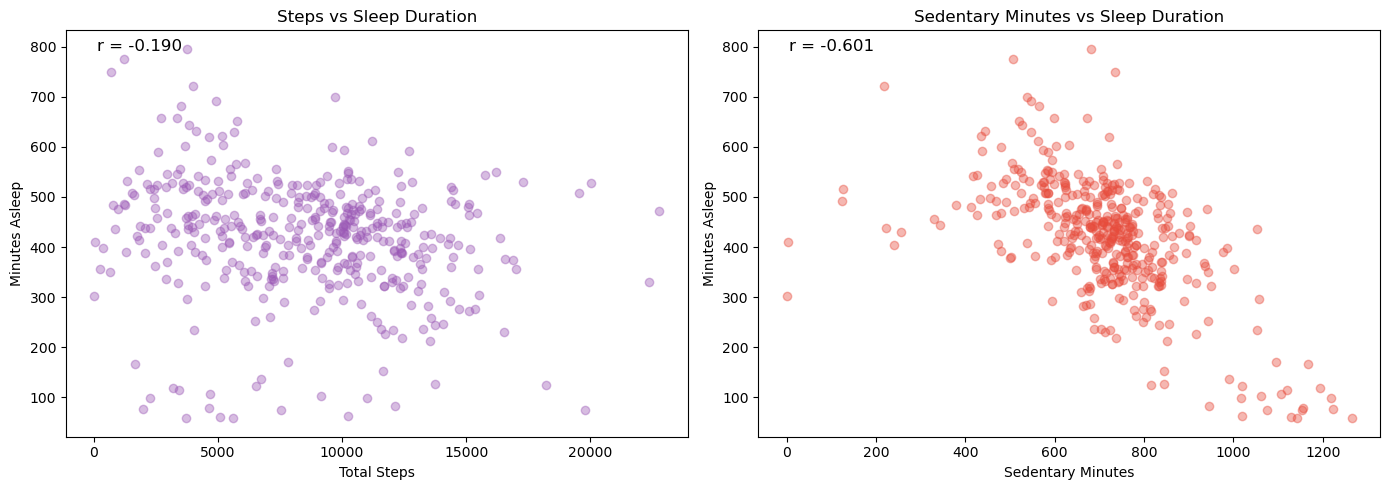

Steps vs Sleep correlation:     -0.190
Sedentary vs Sleep correlation: -0.601


In [30]:
# Use the merged dataframe for this
df_with_sleep = df_merged.dropna(subset=['TotalMinutesAsleep'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Steps vs sleep duration
axes[0].scatter(df_with_sleep['TotalSteps'], df_with_sleep['TotalMinutesAsleep'], alpha=0.4, color='#9b59b6')
axes[0].set_title('Steps vs Sleep Duration')
axes[0].set_xlabel('Total Steps')
axes[0].set_ylabel('Minutes Asleep')
corr1 = df_with_sleep['TotalSteps'].corr(df_with_sleep['TotalMinutesAsleep'])
axes[0].text(0.05, 0.95, f'r = {corr1:.3f}', transform=axes[0].transAxes, fontsize=12)

# Sedentary minutes vs sleep duration
axes[1].scatter(df_with_sleep['SedentaryMinutes'], df_with_sleep['TotalMinutesAsleep'], alpha=0.4, color='#e74c3c')
axes[1].set_title('Sedentary Minutes vs Sleep Duration')
axes[1].set_xlabel('Sedentary Minutes')
axes[1].set_ylabel('Minutes Asleep')
corr2 = df_with_sleep['SedentaryMinutes'].corr(df_with_sleep['TotalMinutesAsleep'])
axes[1].text(0.05, 0.95, f'r = {corr2:.3f}', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

print(f"Steps vs Sleep correlation:     {corr1:.3f}")
print(f"Sedentary vs Sleep correlation: {corr2:.3f}")

In [31]:
# Steps vs Sleep correlation:     -0.190  = weak negative
# Sedentary vs Sleep correlation: -0.601 = moderate negative

=== Sedentary Behavior Summary ===

Average sedentary hours/day:  15.9
Median sedentary hours/day:   17.0
Max sedentary hours/day:      24.0

Users averaging 10+ sedentary hours/day:
  33 of 33 users (100%)


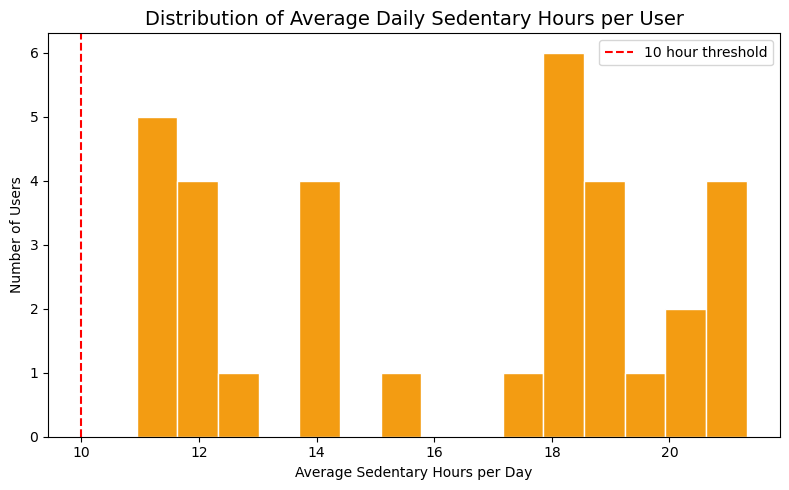

In [32]:
print("=== Sedentary Behavior Summary ===\n")

sedentary_hours = df_activity['SedentaryMinutes'] / 60

print(f"Average sedentary hours/day:  {sedentary_hours.mean():.1f}")
print(f"Median sedentary hours/day:   {sedentary_hours.median():.1f}")
print(f"Max sedentary hours/day:      {sedentary_hours.max():.1f}")
print(f"\nUsers averaging 10+ sedentary hours/day:")

user_sedentary = df_activity.groupby('Id')['SedentaryMinutes'].mean() / 60
high_sedentary = (user_sedentary >= 10).sum()
print(f"  {high_sedentary} of {df_activity['Id'].nunique()} users ({high_sedentary/df_activity['Id'].nunique()*100:.0f}%)")

plt.figure(figsize=(8, 5))
plt.hist(user_sedentary, bins=15, color='#f39c12', edgecolor='white')
plt.title('Distribution of Average Daily Sedentary Hours per User', fontsize=14)
plt.xlabel('Average Sedentary Hours per Day')
plt.ylabel('Number of Users')
plt.axvline(x=10, color='red', linestyle='--', label='10 hour threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
level_order = ['Sedentary', 'Low Active', 'Somewhat Active', 'Active']

comparison = df_activity.groupby('ActivityLevel').agg({
    'TotalSteps': 'mean',
    'Calories': 'mean',
    'SedentaryMinutes': 'mean',
    'TotalActiveMinutes': 'mean'
}).reindex(level_order).round(0)

comparison.columns = ['Avg Steps', 'Avg Calories', 'Avg Sedentary Min', 'Avg Active Min']
print("=== Metrics by Activity Level ===\n")
print(comparison.to_string())

=== Metrics by Activity Level ===

                 Avg Steps  Avg Calories  Avg Sedentary Min  Avg Active Min
ActivityLevel                                                              
Sedentary           3875.0        2112.0             1080.0           164.0
Low Active          6684.0        2162.0             1061.0           226.0
Somewhat Active     8758.0        2487.0              795.0           279.0
Active             12703.0        2583.0              973.0           289.0


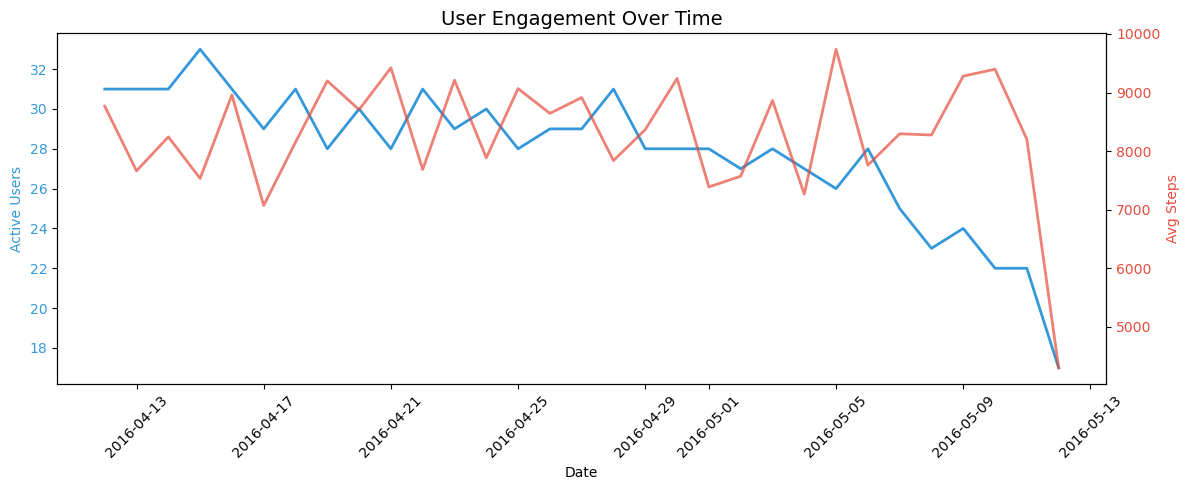

In [34]:
daily_engagement = df_activity.groupby('ActivityDate').agg({
    'Id': 'nunique',
    'TotalSteps': 'mean'
})
daily_engagement.columns = ['Active Users', 'Avg Steps']

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Date')
ax1.set_ylabel('Active Users', color='#3498db')
ax1.plot(daily_engagement.index, daily_engagement['Active Users'], color='#3498db', linewidth=2)
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Avg Steps', color='#e74c3c')
ax2.plot(daily_engagement.index, daily_engagement['Avg Steps'], color='#e74c3c', linewidth=2, alpha=0.7)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('User Engagement Over Time', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Data Source: LifeSnaps Dataset

The LifeSnaps dataset is a multi-modal, longitudinal dataset published in Scientific Data (Nature) by researchers from Aristotle University of Thessaloniki. It contains data collected unobtrusively over 4 months by 71 participants using a Fitbit Sense smartwatch, validated psychological surveys, and ecological momentary assessments. The study was conducted in two rounds: May–July 2021 (n=38) and November 2021–January 2022 (n=34), with participants distributed across Greece, Cyprus, Italy, and Sweden.

The dataset includes 35+ data types covering activity, sleep, heart rate, stress, temperature, mood, and context — along with demographic data (age, gender, BMI) that the FitBit dataset entirely lacks.

**Key limitations:** Sample still relatively small (71 users), convenience sampling from university mailing lists, gender split skews male (42M/27F), entirely European population, some BMI values stored as ranges rather than precise numbers indicating self-reported approximations, high missing data rates across mood, stress, and context columns (69%+), and data is approximately 4 years old.

In [35]:
import pandas as pd

In [36]:
#explore the lifesnaps data
import os

for folder in ['csv_rais_anonymized', 'mongo_rais_anonymized', 'scored_surveys']:
    print(f"\n{'=' * 50}")
    print(f"  {folder}")
    print('=' * 50)
    for root, dirs, files in os.walk(folder):
        level = root.replace(folder, '').count(os.sep)
        indent = '  ' * level
        if level < 2:
            for file in files:
                size_mb = os.path.getsize(os.path.join(root, file)) / (1024 * 1024)
                print(f"{indent}  {file} ({size_mb:.1f} MB)")


  csv_rais_anonymized
  daily_fitbit_sema_df_unprocessed.csv (2.0 MB)
  hourly_fitbit_sema_df_unprocessed.csv (20.2 MB)

  mongo_rais_anonymized
  fitbit.bson (9234.1 MB)
  fitbit.metadata.json (0.0 MB)
  sema.bson (10.2 MB)
  sema.metadata.json (0.0 MB)
  surveys.bson (0.6 MB)
  surveys.metadata.json (0.0 MB)

  scored_surveys
  breq.csv (0.0 MB)
  panas.csv (0.0 MB)
  personality.csv (0.0 MB)
  stai.csv (0.0 MB)
  ttm.csv (0.0 MB)


In [37]:
# Primary data
df_lifesnaps = pd.read_csv("csv_rais_anonymized/daily_fitbit_sema_df_unprocessed.csv")

# Survey data
df_panas = pd.read_csv("scored_surveys/panas.csv")
df_stai = pd.read_csv("scored_surveys/stai.csv")
df_personality = pd.read_csv("scored_surveys/personality.csv")
df_breq = pd.read_csv("scored_surveys/breq.csv")
df_ttm = pd.read_csv("scored_surveys/ttm.csv")

print(f"Daily Fitbit:   {df_lifesnaps.shape}")
print(f"PANAS (mood):   {df_panas.shape}")
print(f"STAI (anxiety): {df_stai.shape}")
print(f"Personality:    {df_personality.shape}")
print(f"BREQ (exercise):{df_breq.shape}")
print(f"TTM (change):   {df_ttm.shape}")

Daily Fitbit:   (7410, 63)
PANAS (mood):   (268, 6)
STAI (anxiety): (279, 6)
Personality:    (50, 15)
BREQ (exercise):(92, 10)
TTM (change):   (94, 15)


In [38]:
print("=== Daily Fitbit Columns ===")
for col in df_lifesnaps.columns:
    print(f"  {col}")

=== Daily Fitbit Columns ===
  Unnamed: 0
  id
  date
  nightly_temperature
  nremhr
  rmssd
  spo2
  full_sleep_breathing_rate
  stress_score
  sleep_points_percentage
  exertion_points_percentage
  responsiveness_points_percentage
  daily_temperature_variation
  badgeType
  calories
  filteredDemographicVO2Max
  distance
  activityType
  bpm
  lightly_active_minutes
  moderately_active_minutes
  very_active_minutes
  sedentary_minutes
  mindfulness_session
  scl_avg
  resting_hr
  sleep_duration
  minutesToFallAsleep
  minutesAsleep
  minutesAwake
  minutesAfterWakeup
  sleep_efficiency
  sleep_deep_ratio
  sleep_wake_ratio
  sleep_light_ratio
  sleep_rem_ratio
  steps
  minutes_in_default_zone_1
  minutes_below_default_zone_1
  minutes_in_default_zone_2
  minutes_in_default_zone_3
  age
  gender
  bmi
  step_goal
  min_goal
  max_goal
  step_goal_label
  ALERT
  HAPPY
  NEUTRAL
  RESTED/RELAXED
  SAD
  TENSE/ANXIOUS
  TIRED
  ENTERTAINMENT
  GYM
  HOME
  HOME_OFFICE
  OTHER
  OUTDOO

### 3.1 Prepare & Validate

In [39]:
print(f"Rows: {df_lifesnaps.shape[0]}")
print(f"Columns: {df_lifesnaps.shape[1]}")
print(f"Unique users: {df_lifesnaps['id'].nunique()}")
print(f"\nDate range: {df_lifesnaps['date'].min()} to {df_lifesnaps['date'].max()}")

Rows: 7410
Columns: 63
Unique users: 71

Date range: 2021-04-08 to 2022-01-22


In [40]:
print("=== BMI unique values ===")
print(df_lifesnaps['bmi'].unique())

=== BMI unique values ===
['<19' '23.0' '28.0' '21.0' '22.0' '24.0' '20.0' '>=25' '29.0' '19.0'
 '>=30' '25.0' '27.0' '26.0' nan]


In [41]:
# Replace range labels with midpoint/representative values
df_lifesnaps['bmi'] = df_lifesnaps['bmi'].replace({
    '<19': '18',      # Below 19, use 18 as estimate
    '>=25': '25.5',   # 25 or above, use 25.5
    '>=30': '31'      # 30 or above, use 31
})

# Convert to numeric
df_lifesnaps['bmi'] = pd.to_numeric(df_lifesnaps['bmi'])

print("=== BMI Summary ===")
print(f"  Min:    {df_lifesnaps['bmi'].min()}")
print(f"  Max:    {df_lifesnaps['bmi'].max()}")
print(f"  Mean:   {df_lifesnaps['bmi'].mean():.1f}")
print(f"  Median: {df_lifesnaps['bmi'].median():.1f}")
print(f"  Nulls:  {df_lifesnaps['bmi'].isnull().sum()}")

=== BMI Summary ===
  Min:    18.0
  Max:    31.0
  Mean:   23.1
  Median: 23.0
  Nulls:  614


In [42]:
print("=== Gender Distribution ===")
print(df_lifesnaps.groupby('gender')['id'].nunique())

print("\n=== Age Distribution ===")
print(df_lifesnaps.groupby('age')['id'].nunique())

print("\n=== BMI Summary ===")
print(f"  Min:    {df_lifesnaps['bmi'].min()}")
print(f"  Max:    {df_lifesnaps['bmi'].max()}")
print(f"  Mean:   {df_lifesnaps['bmi'].mean():.1f}")
print(f"  Median: {df_lifesnaps['bmi'].median():.1f}")

=== Gender Distribution ===
gender
FEMALE    27
MALE      42
Name: id, dtype: int64

=== Age Distribution ===
age
<30     37
>=30    31
Name: id, dtype: int64

=== BMI Summary ===
  Min:    18.0
  Max:    31.0
  Mean:   23.1
  Median: 23.0


In [43]:
df_lifesnaps['date'] = pd.to_datetime(df_lifesnaps['date'])
dupes = df_lifesnaps.duplicated(subset=['id', 'date']).sum()
print(f"Duplicate records (same user + date): {dupes}")

Duplicate records (same user + date): 0


In [44]:
missing = df_lifesnaps.isnull().sum()
missing_pct = (missing / len(df_lifesnaps) * 100).round(1)

missing_report = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_pct
})

print("=== Missing Values (columns with any nulls) ===\n")
print(missing_report[missing_report['Missing'] > 0].sort_values('Percent', ascending=False).to_string())

=== Missing Values (columns with any nulls) ===

                                  Missing  Percent
scl_avg                              7030     94.9
badgeType                            6895     93.0
spo2                                 6140     82.9
stress_score                         5534     74.7
sleep_points_percentage              5534     74.7
exertion_points_percentage           5534     74.7
responsiveness_points_percentage     5534     74.7
max_goal                             5497     74.2
step_goal                            5497     74.2
min_goal                             5497     74.2
step_goal_label                      5495     74.2
activityType                         5197     70.1
RESTED/RELAXED                       5120     69.1
NEUTRAL                              5120     69.1
WORK/SCHOOL                          5120     69.1
HAPPY                                5120     69.1
ALERT                                5120     69.1
TENSE/ANXIOUS                    

In [45]:
key_cols = ['steps', 'calories', 'sedentary_minutes', 'lightly_active_minutes', 
            'moderately_active_minutes', 'very_active_minutes', 'minutesAsleep',
            'sleep_efficiency', 'stress_score', 'resting_hr']

print("=== Key Metrics Summary ===\n")
print(df_lifesnaps[key_cols].describe().round(1).to_string())

=== Key Metrics Summary ===

         steps  calories  sedentary_minutes  lightly_active_minutes  moderately_active_minutes  very_active_minutes  minutesAsleep  sleep_efficiency  stress_score  resting_hr
count   4777.0    6660.0             7083.0                  7083.0                     7083.0               7083.0         3551.0            3551.0        1876.0      4422.0
mean    8261.6    2183.0             1041.7                   131.8                       14.1                 14.5          393.1              93.8          64.2        66.3
std     5475.5     704.2              354.7                   121.1                       23.8                 27.5           98.4               6.3          28.5         7.2
min        0.0       0.7                0.0                     0.0                        0.0                  0.0            0.0              34.0           0.0        44.1
25%     4461.0    1669.5              713.0                     0.0                        0.0  

### 3.2 Clean

The cleaning phase addressed data quality issues specific to the LifeSnaps dataset:
- Converted BMI range labels ('<19', '>=25', '>=30') to numeric approximations — noting that this indicates BMI was self-reported in brackets rather than precisely measured
- Removed zero-step days as likely non-wear days (7,410 → 4,691 records)
- Converted date strings to datetime format
- Created DayOfWeek, TotalActiveMinutes, and ActivityLevel columns using the same CDC thresholds applied to the FitBit data for consistency
- Flagged but retained 2 sleep records over 16 hours and 1 step record over 40,000 given the limited data volume
- Identified usable columns (under 40% missing) for core analysis: steps, calories, active minutes, sedentary minutes, resting heart rate, demographics
- Noted mood, stress, and context columns (69%+ missing) as too sparse for reliable standalone analysis

In [46]:
print(f"Records before: {len(df_lifesnaps)}")

# Remove rows where steps is 0 or null
df_lifesnaps = df_lifesnaps[df_lifesnaps['steps'] > 0]

print(f"Records after removing zero/null steps: {len(df_lifesnaps)}")
print(f"Users remaining: {df_lifesnaps['id'].nunique()}")

Records before: 7410
Records after removing zero/null steps: 4691
Users remaining: 71


In [47]:
# Day of week
df_lifesnaps['date'] = pd.to_datetime(df_lifesnaps['date'])
df_lifesnaps['DayOfWeek'] = df_lifesnaps['date'].dt.day_name()

# Total active minutes
df_lifesnaps['TotalActiveMinutes'] = (
    df_lifesnaps['lightly_active_minutes']
    + df_lifesnaps['moderately_active_minutes']
    + df_lifesnaps['very_active_minutes']
)

# Activity level classification (same CDC thresholds as FitBit)
user_avg_steps = df_lifesnaps.groupby('id')['steps'].mean()

def classify_activity(steps):
    if steps < 5000:
        return 'Sedentary'
    elif steps < 7500:
        return 'Low Active'
    elif steps < 10000:
        return 'Somewhat Active'
    else:
        return 'Active'

user_categories = user_avg_steps.apply(classify_activity).reset_index()
user_categories.columns = ['id', 'ActivityLevel']
df_lifesnaps = df_lifesnaps.merge(user_categories, on='id')

print("Activity level distribution:")
print(df_lifesnaps.groupby('ActivityLevel')['id'].nunique())

Activity level distribution:
ActivityLevel
Active             19
Low Active         30
Sedentary           3
Somewhat Active    19
Name: id, dtype: int64


In [48]:
# Sleep over 16 hours (960 min) is implausible
sleep_outliers = df_lifesnaps['minutesAsleep'] > 960
print(f"Sleep records over 16 hours: {sleep_outliers.sum()}")

# Steps over 40,000
step_outliers = df_lifesnaps['steps'] > 40000
print(f"Step records over 40,000: {step_outliers.sum()}")

Sleep records over 16 hours: 2
Step records over 40,000: 1


In [49]:
print("=" * 50)
print("  LIFESNAPS CLEANED DATA SUMMARY")
print("=" * 50)
print(f"\n  Total records:        {len(df_lifesnaps)}")
print(f"  Unique users:         {df_lifesnaps['id'].nunique()}")
print(f"  Date range:           {df_lifesnaps['date'].min().date()} to {df_lifesnaps['date'].max().date()}")
print(f"  Female users:         {df_lifesnaps[df_lifesnaps['gender']=='FEMALE']['id'].nunique()}")
print(f"  Male users:           {df_lifesnaps[df_lifesnaps['gender']=='MALE']['id'].nunique()}")
print(f"\n  Records with sleep:   {df_lifesnaps['minutesAsleep'].notna().sum()}")
print(f"  Records with stress:  {df_lifesnaps['stress_score'].notna().sum()}")
print(f"  Records with HR:      {df_lifesnaps['resting_hr'].notna().sum()}")

  LIFESNAPS CLEANED DATA SUMMARY

  Total records:        4691
  Unique users:         71
  Date range:           2021-05-24 to 2022-01-21
  Female users:         27
  Male users:           42

  Records with sleep:   3536
  Records with stress:  1870
  Records with HR:      4412


### 3.3 Analyze

In [50]:
print("=" * 50)
print("  LIFESNAPS OVERALL USAGE SUMMARY")
print("=" * 50)
print(f"\n  Average daily steps:          {df_lifesnaps['steps'].mean():.0f}")
print(f"  Average daily calories:       {df_lifesnaps['calories'].mean():.0f}")
print(f"  Average active minutes:       {df_lifesnaps['TotalActiveMinutes'].mean():.0f}")
print(f"  Average sedentary minutes:    {df_lifesnaps['sedentary_minutes'].mean():.0f}")
print(f"  Average sedentary hours:      {df_lifesnaps['sedentary_minutes'].mean() / 60:.1f}")
print(f"\n  Average sleep (minutes):      {df_lifesnaps['minutesAsleep'].mean():.0f}")
print(f"  Average sleep (hours):        {df_lifesnaps['minutesAsleep'].mean() / 60:.1f}")
print(f"  Average sleep efficiency:     {df_lifesnaps['sleep_efficiency'].mean():.1f}%")
print(f"  Average resting heart rate:   {df_lifesnaps['resting_hr'].mean():.1f} bpm")

  LIFESNAPS OVERALL USAGE SUMMARY

  Average daily steps:          8413
  Average daily calories:       2409
  Average active minutes:       242
  Average sedentary minutes:    844
  Average sedentary hours:      14.1

  Average sleep (minutes):      393
  Average sleep (hours):        6.6
  Average sleep efficiency:     93.8%
  Average resting heart rate:   66.3 bpm


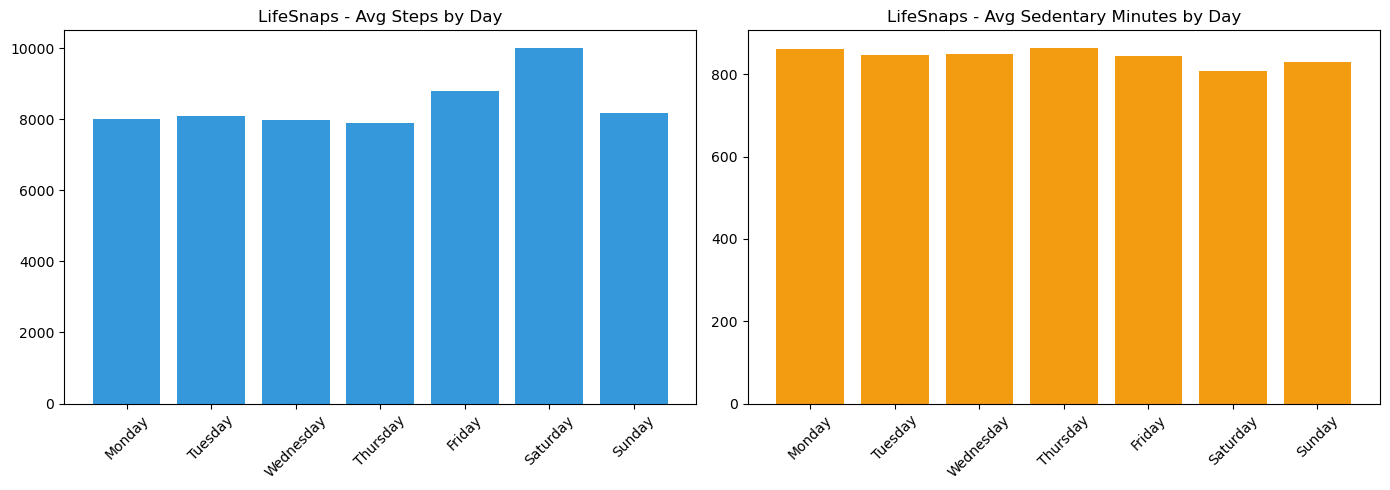

In [51]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

ls_daily = df_lifesnaps.groupby('DayOfWeek').agg({
    'steps': 'mean',
    'sedentary_minutes': 'mean'
}).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ls_daily.index, ls_daily['steps'], color='#3498db')
axes[0].set_title('LifeSnaps - Avg Steps by Day')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(ls_daily.index, ls_daily['sedentary_minutes'], color='#f39c12')
axes[1].set_title('LifeSnaps - Avg Sedentary Minutes by Day')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [52]:
gender_stats = df_lifesnaps.groupby('gender').agg({
    'steps': 'mean',
    'calories': 'mean',
    'sedentary_minutes': 'mean',
    'TotalActiveMinutes': 'mean',
    'minutesAsleep': 'mean'
}).round(0)

gender_stats.columns = ['Avg Steps', 'Avg Calories', 'Avg Sedentary Min', 'Avg Active Min', 'Avg Sleep Min']
print("=== Metrics by Gender ===\n")
print(gender_stats.to_string())

=== Metrics by Gender ===

        Avg Steps  Avg Calories  Avg Sedentary Min  Avg Active Min  Avg Sleep Min
gender                                                                           
FEMALE     8849.0        2057.0              817.0           263.0          400.0
MALE       8429.0        2699.0              868.0           235.0          382.0


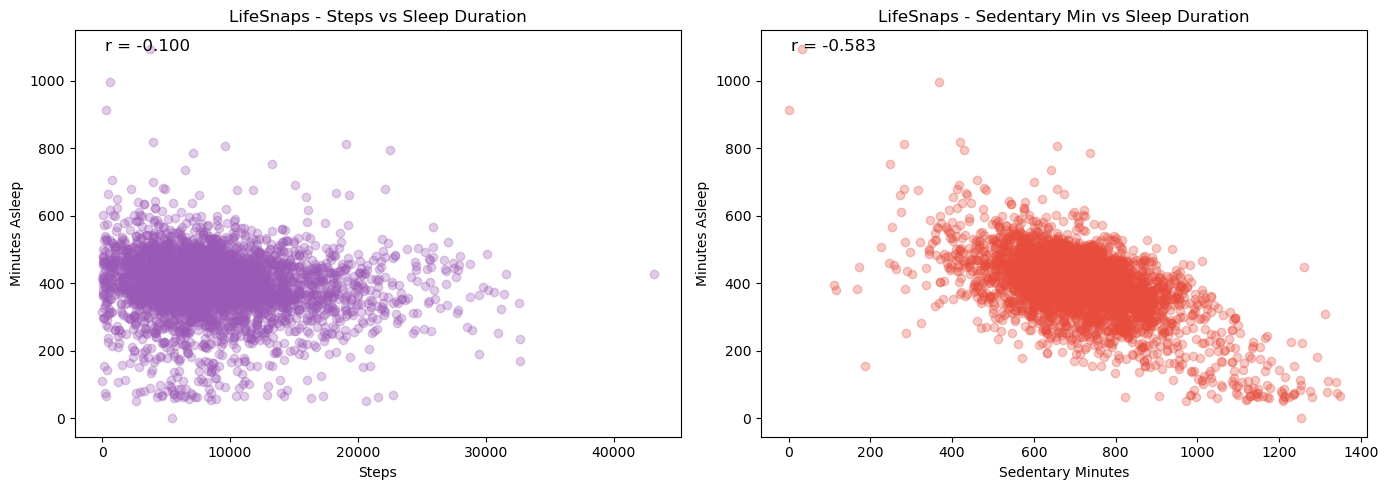

Steps vs Sleep correlation:     -0.100
Sedentary vs Sleep correlation: -0.583


In [53]:
ls_with_sleep = df_lifesnaps.dropna(subset=['minutesAsleep'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ls_with_sleep['steps'], ls_with_sleep['minutesAsleep'], alpha=0.3, color='#9b59b6')
axes[0].set_title('LifeSnaps - Steps vs Sleep Duration')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Minutes Asleep')
corr1 = ls_with_sleep['steps'].corr(ls_with_sleep['minutesAsleep'])
axes[0].text(0.05, 0.95, f'r = {corr1:.3f}', transform=axes[0].transAxes, fontsize=12)

axes[1].scatter(ls_with_sleep['sedentary_minutes'], ls_with_sleep['minutesAsleep'], alpha=0.3, color='#e74c3c')
axes[1].set_title('LifeSnaps - Sedentary Min vs Sleep Duration')
axes[1].set_xlabel('Sedentary Minutes')
axes[1].set_ylabel('Minutes Asleep')
corr2 = ls_with_sleep['sedentary_minutes'].corr(ls_with_sleep['minutesAsleep'])
axes[1].text(0.05, 0.95, f'r = {corr2:.3f}', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

print(f"Steps vs Sleep correlation:     {corr1:.3f}")
print(f"Sedentary vs Sleep correlation: {corr2:.3f}")

Average sedentary hours/day:  14.1
Median sedentary hours/day:   12.8

Users averaging 10+ sedentary hours: 69 of 71 (97%)


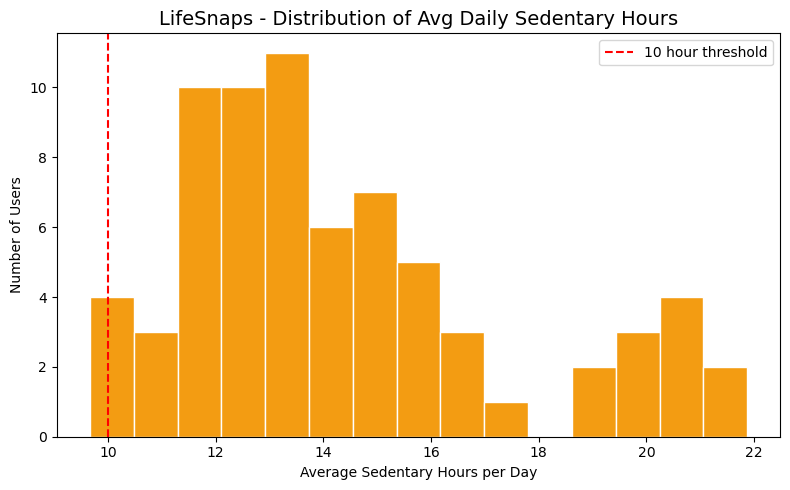

In [54]:
user_sedentary = df_lifesnaps.groupby('id')['sedentary_minutes'].mean() / 60
high_sedentary = (user_sedentary >= 10).sum()

print(f"Average sedentary hours/day:  {df_lifesnaps['sedentary_minutes'].mean()/60:.1f}")
print(f"Median sedentary hours/day:   {df_lifesnaps['sedentary_minutes'].median()/60:.1f}")
print(f"\nUsers averaging 10+ sedentary hours: {high_sedentary} of {df_lifesnaps['id'].nunique()} ({high_sedentary/df_lifesnaps['id'].nunique()*100:.0f}%)")

plt.figure(figsize=(8, 5))
plt.hist(user_sedentary, bins=15, color='#f39c12', edgecolor='white')
plt.title('LifeSnaps - Distribution of Avg Daily Sedentary Hours', fontsize=14)
plt.xlabel('Average Sedentary Hours per Day')
plt.ylabel('Number of Users')
plt.axvline(x=10, color='red', linestyle='--', label='10 hour threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Cross-Dataset Comparison

In [55]:
print("=" * 60)
print("  FITBIT vs LIFESNAPS COMPARISON")
print("=" * 60)
print(f"\n{'Metric':<30} {'FitBit':>10} {'LifeSnaps':>10}")
print("-" * 52)
print(f"{'Unique users':<30} {df_activity['Id'].nunique():>10} {df_lifesnaps['id'].nunique():>10}")
print(f"{'Avg daily steps':<30} {df_activity['TotalSteps'].mean():>10.0f} {df_lifesnaps['steps'].mean():>10.0f}")
print(f"{'Avg calories':<30} {df_activity['Calories'].mean():>10.0f} {df_lifesnaps['calories'].mean():>10.0f}")
print(f"{'Avg sedentary hours':<30} {df_activity['SedentaryMinutes'].mean()/60:>10.1f} {df_lifesnaps['sedentary_minutes'].mean()/60:>10.1f}")
print(f"{'Avg active minutes':<30} {df_activity['TotalActiveMinutes'].mean():>10.0f} {df_lifesnaps['TotalActiveMinutes'].mean():>10.0f}")
print(f"{'Avg sleep (hours)':<30} {df_sleep['TotalMinutesAsleep'].mean()/60:>10.1f} {df_lifesnaps['minutesAsleep'].mean()/60:>10.1f}")
print(f"{'Avg sleep efficiency':<30} {df_sleep['SleepEfficiency'].mean():>10.1f}% {df_lifesnaps['sleep_efficiency'].mean():>10.1f}%")
print(f"{'Steps-sleep correlation':<30} {-0.190:>10.3f} {df_lifesnaps.dropna(subset=['minutesAsleep'])['steps'].corr(df_lifesnaps.dropna(subset=['minutesAsleep'])['minutesAsleep']):>10.3f}")
print(f"{'Sedentary-sleep correlation':<30} {-0.601:>10.3f} {df_lifesnaps.dropna(subset=['minutesAsleep'])['sedentary_minutes'].corr(df_lifesnaps.dropna(subset=['minutesAsleep'])['minutesAsleep']):>10.3f}")
print(f"{'Users 10+ sedentary hrs':<30} {'33/33':>10} {'69/71':>10}")

  FITBIT vs LIFESNAPS COMPARISON

Metric                             FitBit  LifeSnaps
----------------------------------------------------
Unique users                           33         71
Avg daily steps                      8319       8413
Avg calories                         2361       2409
Avg sedentary hours                  15.9       14.1
Avg active minutes                    248        242
Avg sleep (hours)                     7.0        6.6
Avg sleep efficiency                 91.6%       93.8%
Steps-sleep correlation            -0.190     -0.100
Sedentary-sleep correlation        -0.601     -0.583
Users 10+ sedentary hrs             33/33      69/71


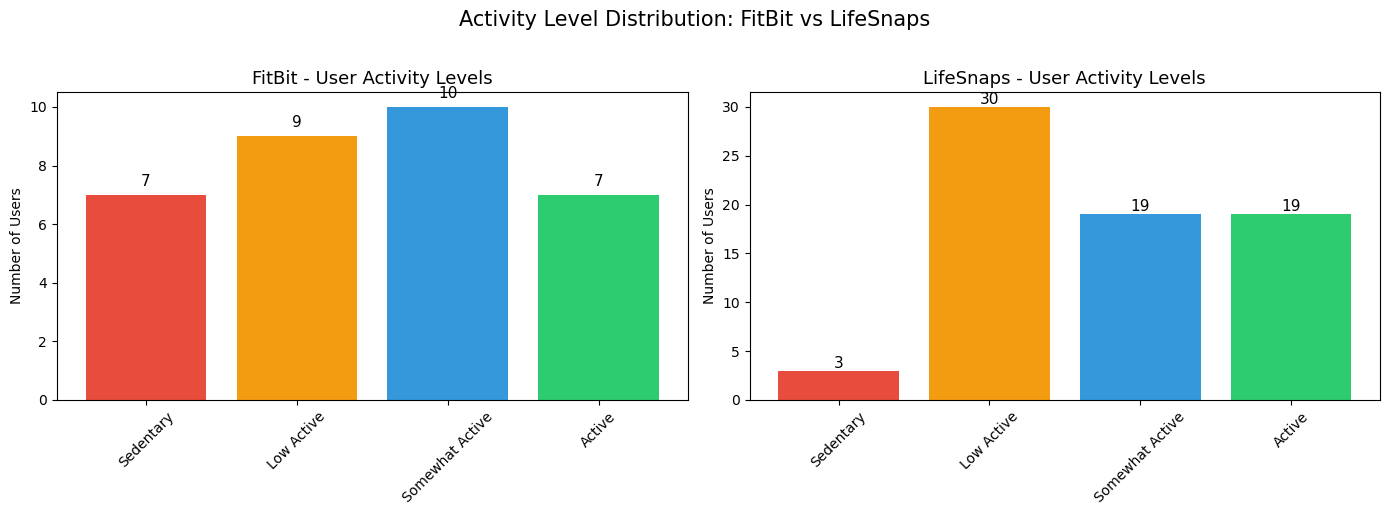

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

level_order = ['Sedentary', 'Low Active', 'Somewhat Active', 'Active']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# FitBit
fb_levels = df_activity.groupby('ActivityLevel')['Id'].nunique().reindex(level_order)
axes[0].bar(fb_levels.index, fb_levels.values, color=colors)
axes[0].set_title('FitBit - User Activity Levels', fontsize=13)
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(axes[0].patches, fb_levels.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(count), ha='center', fontsize=11)

# LifeSnaps
ls_levels = df_lifesnaps.groupby('ActivityLevel')['id'].nunique().reindex(level_order)
axes[1].bar(ls_levels.index, ls_levels.values, color=colors)
axes[1].set_title('LifeSnaps - User Activity Levels', fontsize=13)
axes[1].set_ylabel('Number of Users')
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(axes[1].patches, ls_levels.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(count), ha='center', fontsize=11)

plt.suptitle('Activity Level Distribution: FitBit vs LifeSnaps', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

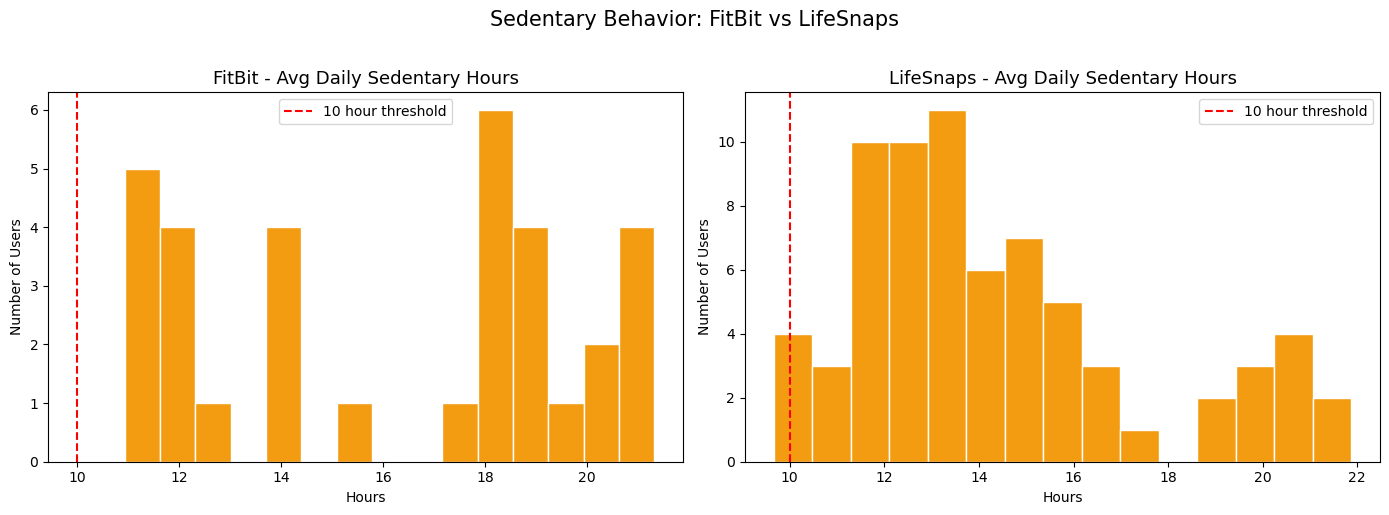

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FitBit sedentary distribution
fb_sedentary = df_activity.groupby('Id')['SedentaryMinutes'].mean() / 60
axes[0].hist(fb_sedentary, bins=15, color='#f39c12', edgecolor='white')
axes[0].set_title('FitBit - Avg Daily Sedentary Hours', fontsize=13)
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(x=10, color='red', linestyle='--', label='10 hour threshold')
axes[0].legend()

# LifeSnaps sedentary distribution
ls_sedentary = df_lifesnaps.groupby('id')['sedentary_minutes'].mean() / 60
axes[1].hist(ls_sedentary, bins=15, color='#f39c12', edgecolor='white')
axes[1].set_title('LifeSnaps - Avg Daily Sedentary Hours', fontsize=13)
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(x=10, color='red', linestyle='--', label='10 hour threshold')
axes[1].legend()

plt.suptitle('Sedentary Behavior: FitBit vs LifeSnaps', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

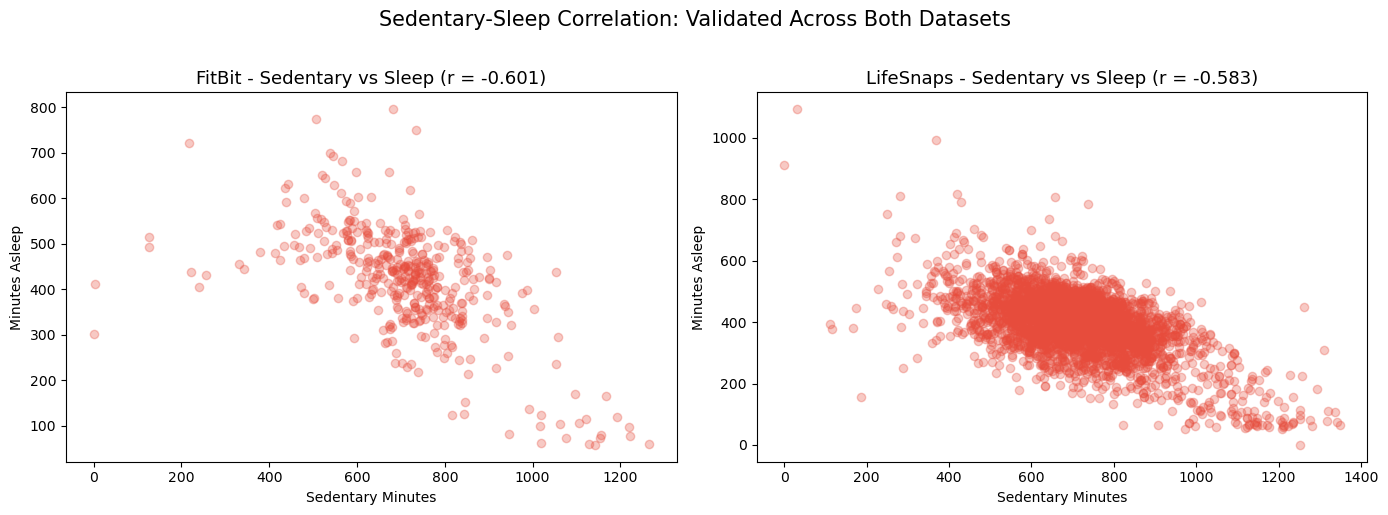

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FitBit
fb_sleep = df_merged.dropna(subset=['TotalMinutesAsleep'])
axes[0].scatter(fb_sleep['SedentaryMinutes'], fb_sleep['TotalMinutesAsleep'], alpha=0.3, color='#e74c3c')
axes[0].set_title(f'FitBit - Sedentary vs Sleep (r = -0.601)', fontsize=13)
axes[0].set_xlabel('Sedentary Minutes')
axes[0].set_ylabel('Minutes Asleep')

# LifeSnaps
ls_sleep = df_lifesnaps.dropna(subset=['minutesAsleep'])
axes[1].scatter(ls_sleep['sedentary_minutes'], ls_sleep['minutesAsleep'], alpha=0.3, color='#e74c3c')
corr = ls_sleep['sedentary_minutes'].corr(ls_sleep['minutesAsleep'])
axes[1].set_title(f'LifeSnaps - Sedentary vs Sleep (r = {corr:.3f})', fontsize=13)
axes[1].set_xlabel('Sedentary Minutes')
axes[1].set_ylabel('Minutes Asleep')

plt.suptitle('Sedentary-Sleep Correlation: Validated Across Both Datasets', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Findings & Recommendations

### Finding 1: Most users fall short of recommended activity levels

Across both datasets, average daily steps landed between 8,300 and 8,400 — below the widely recommended 10,000-step benchmark. In the FitBit data, all 33 users were distributed across four activity categories, with the Sedentary group averaging just 3,875 steps and the Active group averaging 12,703. The LifeSnaps data showed a similar spread, with 33 of 71 users (46%) falling into the Sedentary or Low Active categories. The consistency of these averages across two datasets separated by five years and two continents suggests that under-activity is a persistent behavioral norm among smart device users.

**Recommendation:** Bellabeat should position its products around meeting users where they are rather than imposing a one-size-fits-all 10,000-step goal. Personalized, progressive step targets that start from the user's actual baseline would feel achievable rather than discouraging. Marketing messaging should emphasize "every step counts" and celebrate incremental improvement over absolute benchmarks.

### Finding 2: Sedentary behavior is the dominant pattern across all users

This was the single strongest finding in the entire analysis. In the FitBit data, every single user (33 of 33, 100%) averaged over 10 sedentary hours per day, with an average of 15.9 hours and a median of 17.0 hours. The LifeSnaps data confirmed this pattern — 69 of 71 users (97%) exceeded 10 sedentary hours daily, averaging 14.1 hours. Even users classified as Active in the FitBit data still averaged 973 sedentary minutes (16.2 hours) per day, demonstrating that exercise is typically concentrated into short windows while the rest of the day remains inactive.

**Recommendation:** This is Bellabeat's single biggest product and marketing opportunity. Inactivity alerts and movement reminders should be a core feature. Bellabeat can differentiate from competitors by framing these nudges not as fitness pressure but as wellness awareness — aligned with the brand's identity of empowering women's health. Marketing campaigns should lead with the insight that "most of your day is spent still, even if you exercise" and position Bellabeat as the product that helps users build movement into their entire day.

### Finding 3: Sedentary behavior is meaningfully linked to shorter sleep

Both datasets showed a consistent negative correlation between sedentary time and sleep duration. The FitBit data returned a correlation of r = -0.601, and the LifeSnaps data confirmed this at r = -0.583. These are moderate-to-strong negative correlations, indicating that more sedentary time is meaningfully associated with less sleep across both populations. By contrast, the relationship between steps and sleep was weak in both datasets (r = -0.190 in FitBit, r = -0.100 in LifeSnaps), suggesting that it is prolonged inactivity — not the absence of exercise — that most affects sleep. Average sleep across both datasets fell between 6.5 and 7.0 hours, at or just below the CDC's recommended 7–9 hours.

**Recommendation:** Bellabeat should market its sleep and activity tracking as an integrated wellness story rather than separate features. The data shows that reducing sedentary time has a stronger connection to sleep than increasing step counts does. Showing users how their daytime inactivity directly affects their nighttime rest creates a compelling feedback loop. In-app insights like "you were sedentary for 14 hours today — users with similar patterns tend to sleep 40 minutes less" would make the connection tangible.

### Finding 4: Steps and calories are positively correlated, but the relationship is moderate

The FitBit data showed a correlation of r = 0.562 between total steps and calories burned — a positive but moderate relationship. This means that while more steps generally lead to more calories burned, steps alone do not fully explain calorie expenditure. Factors like activity intensity, body composition, and basal metabolic rate all play a role. Users classified as Active burned an average of 2,583 calories compared to 2,112 for Sedentary users — a meaningful but not dramatic difference.

**Recommendation:** Bellabeat should avoid marketing that implies a simple "more steps = more calories burned" equation. Instead, the product should educate users about intensity — showing that 30 minutes of vigorous activity can be more impactful than thousands of additional low-intensity steps. Features that highlight active minutes and intensity zones alongside step counts would provide a more accurate and motivating picture.

### Finding 5: Activity patterns vary by day of week

Both datasets showed that activity levels were not uniform across the week. Midweek days tended to show higher step counts, while certain days showed dips in activity and increases in sedentary time — suggesting movement is largely driven by routine rather than deliberate exercise.

**Recommendation:** Bellabeat should time motivational content and push notifications to target low-activity days specifically. A "Sunday Spark" or "Monday Momentum" campaign could address the weekend-to-weekday transition. Weekly summary emails sent on Friday could reinforce achievements and set goals for the weekend.

### Finding 6: Female users are more active than male users

The LifeSnaps data — the only dataset with demographic information — revealed that female users averaged more daily steps (8,849 vs 8,429), more active minutes (263 vs 235), and more sleep (400 vs 382 minutes) than male users.

**Recommendation:** Rather than marketing to women as if they need to start being active, Bellabeat should speak to an audience that is already motivated but looking for smarter, more holistic tools. Messaging should focus on optimization and insight — "understand your patterns" rather than "get moving."

### Finding 7: Engagement and data completeness vary significantly

Both datasets showed uneven participation across data types. In the FitBit data, only 24 of 33 users logged sleep and just 8 logged weight. In LifeSnaps, mood and stress columns were over 69% null. Users are willing to passively track steps but far less consistent with features requiring manual input or overnight wear.

**Recommendation:** Bellabeat should prioritize passive tracking features that require no user effort over features that depend on manual logging. For features that do require engagement, gamification strategies such as streaks, milestones, and weekly summaries can encourage consistency.

---
## 6. Limitations

These findings should be treated as directional insights rather than definitive conclusions. The FitBit dataset is over 10 years old, contains only 33 users with no demographic information, and was collected over just 31 days from a self-selected, compensated sample. The LifeSnaps dataset addresses many of these gaps with 71 users, demographic data, and a 4-month collection window, but its sample skews male (59%), is entirely European, and was recruited through university mailing lists. Some BMI values in the LifeSnaps data were recorded as ranges rather than precise numbers, limiting the precision of body composition analysis. Neither dataset is independently sufficient to represent Bellabeat's global target audience, but where their findings converge — particularly around sedentary behavior and the activity-sleep connection — the consistency across time periods, geographies, and populations strengthens the case for action.